In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/473.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/537.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/521.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/436.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/516.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/474.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/501.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/429.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/489.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset/Test/Healthy/RGB/476.jpg
/kaggle/input/datasets/pran84/diabetic-footulcer-d

In [2]:
import os, hashlib, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

BASE = '/kaggle/input/datasets/pran84/diabetic-footulcer-dataset/Full_dataset'
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}
CLASS_NAMES    = ['Healthy', 'Grade1', 'Grade2', 'Grade3', 'Grade4']
LABEL_MAP      = {name: i for i, name in enumerate(CLASS_NAMES)}
CLASS_PATHS    = {
    'Healthy': f'{BASE}/Train/Healthy/RGB',
    'Grade1' : f'{BASE}/Train/Severity/Grade1',
    'Grade2' : f'{BASE}/Train/Severity/Grade2',
    'Grade3' : f'{BASE}/Train/Severity/Grade3',
    'Grade4' : f'{BASE}/Train/Severity/Grade4',
}

# DataFrame
rows = []
for cls, folder in CLASS_PATHS.items():
    for img in os.listdir(folder):
        if os.path.splitext(img)[1].lower() in IMG_EXTENSIONS:
            rows.append({'filepath': os.path.join(folder, img),
                         'class_name': cls, 'label': LABEL_MAP[cls]})
df = pd.DataFrame(rows)

# شيل Duplicates
df['hash']  = df['filepath'].apply(lambda p: hashlib.md5(open(p,'rb').read()).hexdigest())
df_clean    = df.drop_duplicates(subset='hash', keep='first').reset_index(drop=True)

# Oversample Healthy
healthy     = df_clean[df_clean['class_name'] == 'Healthy']
others      = df_clean[df_clean['class_name'] != 'Healthy']
df_balanced = pd.concat([healthy.sample(2000, replace=True, random_state=42), others], ignore_index=True)

# Train/Val Split
train_df, val_df = train_test_split(df_balanced, test_size=0.15,
                                     stratify=df_balanced['class_name'], random_state=42)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

train_paths  = train_df['filepath'].values
train_labels = train_df['label'].values
val_paths    = val_df['filepath'].values
val_labels   = val_df['label'].values

print(f'✅ Train: {len(train_df)} | Val: {len(val_df)}')
print(df_balanced['class_name'].value_counts())

✅ Train: 10122 | Val: 1787
class_name
Grade3     2779
Grade2     2420
Grade4     2387
Grade1     2323
Healthy    2000
Name: count, dtype: int64


In [3]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE   = 224
BATCH_SIZE = 32

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(len(train_df), seed=42)
train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment,             num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f'✅ Train batches: {len(train_ds)} | Val batches: {len(val_ds)}')

2026-05-01 11:48:09.423485: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777636089.643429      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777636089.705766      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777636090.220820      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777636090.220863      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777636090.220866      57 computation_placer.cc:177] computation placer alr

✅ Train batches: 317 | Val batches: 56


In [4]:
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

tf.keras.backend.clear_session()

base = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224,224,3))
base.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
x       = layers.Dense(5, activation='softmax')(x)
model   = tf.keras.Model(inputs, x)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print('✅ Model ready')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model ready


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(filepath='best_model_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history1 = model.fit(train_ds, epochs=30, validation_data=val_ds,
                     callbacks=callbacks, verbose=1)
print(f'✅ Phase 1: {max(history1.history["val_accuracy"]):.4f}')

Epoch 1/30


I0000 00:00:1777636124.796449     143 service.cc:152] XLA service 0x79a344111b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777636124.796516     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777636124.796523     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777636125.977040     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-01 11:48:55.158063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 11:48:55.295584: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777636138.130101     143 device_co

315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5193 - loss: 1.5115

2026-05-01 11:49:15.591286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 11:49:15.734107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 11:49:15.870703: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5196 - loss: 1.5099

2026-05-01 11:49:33.792223: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 11:49:33.929427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.69222, saving model to best_model_phase1.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 57s 121ms/step - accuracy: 0.5198 - loss: 1.5091 - val_accuracy: 0.6922 - val_loss: 0.7532 - learning_rate: 0.0010
Epoch 2/30
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6493 - loss: 0.8889
Epoch 2: val_accuracy improved from 0.69222 to 0.72524, saving model to best_model_phase1.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.6493 - loss: 0.8888 - val_accuracy: 0.7252 - val_loss: 0.6778 - learning_rate: 0.0010
Epoch 3/30
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6888 - loss: 0.7659
Epoch 3: val_accuracy improved from 0.72524 to 0.75881, saving model to best_model_phase1.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6888 - loss: 0.7660 - val_accuracy: 0.7588 - val_loss: 0.6269 - learning_rate: 0.0010
Epoch 4/30
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7025 - loss: 0.7284
Epoch 4: val_accuracy i

In [6]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(filepath='best_model_finetune.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_ft = model.fit(train_ds, epochs=60, validation_data=val_ds,
                       callbacks=callbacks_ft, verbose=1)
print(f'✅ Fine-Tune: {max(history_ft.history["val_accuracy"]):.4f}')

Epoch 1/60
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6777 - loss: 0.9375
Epoch 1: val_accuracy improved from -inf to 0.79463, saving model to best_model_finetune.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 46s 90ms/step - accuracy: 0.6778 - loss: 0.9373 - val_accuracy: 0.7946 - val_loss: 0.7386 - learning_rate: 1.0000e-05
Epoch 2/60
316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7299 - loss: 0.7477
Epoch 2: val_accuracy improved from 0.79463 to 0.80806, saving model to best_model_finetune.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7300 - loss: 0.7476 - val_accuracy: 0.8081 - val_loss: 0.6266 - learning_rate: 1.0000e-05
Epoch 3/60
315/317 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7482 - loss: 0.6751
Epoch 3: val_accuracy improved from 0.80806 to 0.83436, saving model to best_model_finetune.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7483 - loss: 0.6748 - val_accuracy: 0.8344 - val_loss: 0.4860 - learning_rate: 1.0000e-05
Epoch 4

In [7]:
model.export('dfu_savedmodel')
import shutil
shutil.make_archive('dfu_savedmodel', 'zip', 'dfu_savedmodel')
print(f'✅ {os.path.getsize("dfu_savedmodel.zip")/1024/1024:.1f} MB')

INFO:tensorflow:Assets written to: dfu_savedmodel/assets


INFO:tensorflow:Assets written to: dfu_savedmodel/assets


Saved artifact at 'dfu_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133746151817680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151826320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151827472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151828624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151827664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151825936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151829008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151829776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151829392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151826512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133746151828

In [8]:
# ======= 1. حفظ الموديل =======
model.save('dfu_model_final.keras')
model.save('dfu_model_final.h5')
print('✅ dfu_model_final.keras')
print('✅ dfu_model_final.h5')

✅ dfu_model_final.keras
✅ dfu_model_final.h5


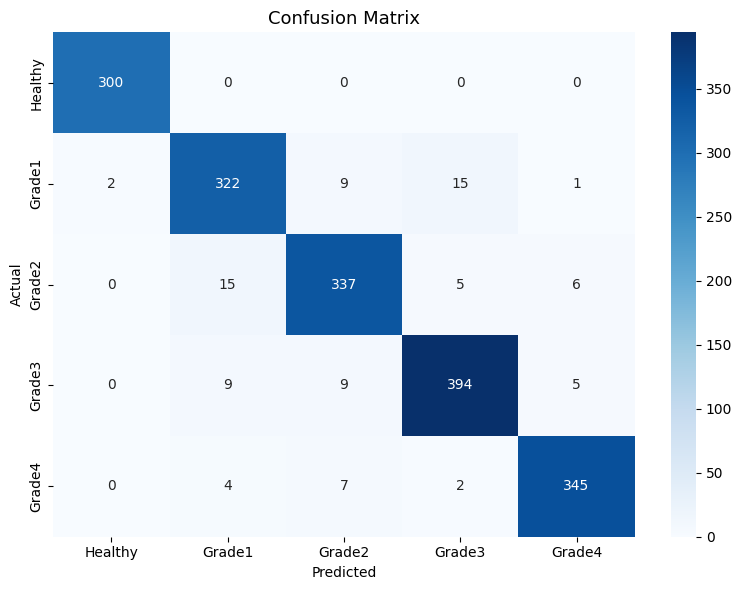

              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       300
      Grade1       0.92      0.92      0.92       349
      Grade2       0.93      0.93      0.93       363
      Grade3       0.95      0.94      0.95       417
      Grade4       0.97      0.96      0.97       358

    accuracy                           0.95      1787
   macro avg       0.95      0.95      0.95      1787
weighted avg       0.95      0.95      0.95      1787



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
# ======= 2. Confusion Matrix =======
y_true, y_pred = [], []
for imgs, labels in val_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [11]:
# ======= 3. Skin Detection Test =======
import cv2

def is_foot_image(img_array, skin_threshold=0.25):
    img_ycrcb  = cv2.cvtColor(img_array, cv2.COLOR_RGB2YCrCb)
    mask_ycrcb = cv2.inRange(img_ycrcb,
                              np.array([0, 133, 77],  dtype=np.uint8),
                              np.array([255, 173, 127], dtype=np.uint8))
    img_hsv   = cv2.cvtColor(cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV)
    mask_hsv  = cv2.inRange(img_hsv,
                             np.array([0, 15, 50],   dtype=np.uint8),
                             np.array([25, 200, 255], dtype=np.uint8))
    combined   = cv2.bitwise_and(mask_ycrcb, mask_hsv)
    skin_ratio = np.sum(combined > 0) / (img_array.shape[0] * img_array.shape[1])
    return skin_ratio >= skin_threshold, float(skin_ratio)

def predict_image(img_path):
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    
    img_cv    = cv2.imread(img_path)
    img_rgb   = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    is_skin, ratio = is_foot_image(img_rgb)
    
    if not is_skin:
        return {'prediction': 'Not a foot', 'confidence': 0.0, 'skin_ratio': ratio}
    
    img_resized = cv2.resize(img_rgb, (224, 224)).astype(np.float32)
    img_input   = np.expand_dims(preprocess_input(img_resized), axis=0)
    preds       = model.predict(img_input, verbose=0)[0]
    confidence  = float(np.max(preds))
    pred_class  = CLASS_NAMES[int(np.argmax(preds))]
    
    top2 = np.sort(preds)[-2:]
    if (top2[1] - top2[0]) < 0.10 or confidence < 0.60:
        return {'prediction': 'Undefined', 'confidence': confidence, 'skin_ratio': ratio}
    
    return {'prediction': pred_class, 'confidence': confidence, 'skin_ratio': ratio}

# اختبار على صور القدم
print('\n=== اختبار على صور القدم ===')
for cls in CLASS_NAMES:
    sample = df_clean[df_clean['class_name'] == cls].sample(1, random_state=42).iloc[0]
    result = predict_image(sample['filepath'])
    status = '✅' if result['prediction'] == cls else '❌'
    print(f'{status} الفعلي: {cls:<10} التوقع: {result["prediction"]:<10} الثقة: {result["confidence"]:.1%}')

# اختبار على صور مش قدم (Ulcer مع ضمادات)
import glob
print('\n=== اختبار على صور Ulcer ===')
ulcer_imgs = glob.glob(f'{BASE}/Train/Ulcer/RGB/*.jpg')[:5]
for img_path in ulcer_imgs:
    result = predict_image(img_path)
    print(f'  التوقع: {result["prediction"]:<15} skin_ratio: {result["skin_ratio"]:.1%}')


=== اختبار على صور القدم ===


2026-05-01 12:18:33.970512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 12:18:34.103965: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


✅ الفعلي: Healthy    التوقع: Healthy    الثقة: 100.0%
✅ الفعلي: Grade1     التوقع: Grade1     الثقة: 100.0%
✅ الفعلي: Grade2     التوقع: Grade2     الثقة: 99.9%
✅ الفعلي: Grade3     التوقع: Grade3     الثقة: 100.0%
✅ الفعلي: Grade4     التوقع: Grade4     الثقة: 99.8%

=== اختبار على صور Ulcer ===
  التوقع: Grade4          skin_ratio: 69.9%
  التوقع: Grade1          skin_ratio: 26.6%
  التوقع: Grade1          skin_ratio: 51.4%
  التوقع: Grade1          skin_ratio: 60.5%
  التوقع: Grade2          skin_ratio: 71.1%
